### Replicating the music brainz dataset with splink for checking
Previous experiments were done with artificial data generated with a specific ruleset in mind, which supported splink usage. We attempt to replicate the results we have in the previous attempt with a public dataset, to 

1) replicate QR3's results 
2) identify potential edge cases/situations where splink might not be enough for global assignment

In [5]:
import pandas as pd

import os, sys

# ---- 1️⃣ Find the directory that holds the `em_pipeline` package ----
# Start from the notebook’s directory (or the current working directory)
start = os.path.abspath(os.getcwd())
if "__file__" in globals():                     # works when run as a script
    start = os.path.abspath(os.path.dirname(__file__))

# Walk up the tree until we see a folder called `em_pipeline`
repo_root = start
while True:
    if os.path.isdir(os.path.join(repo_root,"helpers", "em_pipeline")):
        break                                   # we found it
    parent = os.path.dirname(repo_root)
    if parent == repo_root:                     # reached filesystem root → give up
        raise RuntimeError("Could not find a directory containing 'em_pipeline'")
    repo_root = parent

# ---- 2️⃣ Insert it at the front of sys.path (if not already there) ----
helpers_path = os.path.join(repo_root, 'helpers')
if helpers_path not in sys.path:
    sys.path.insert(0, helpers_path)


from em_pipeline.data_loader import load_pair_dfs_from_paths, standardise_dt
from em_pipeline.splink_helper import (
    build_api_with_con,
    get_blocking_rules,
    get_estimating_blocking_rules,
    get_numerical_comparison,
    get_datetime_comparison,
    get_category_comparison
)
from splink import DuckDBAPI, Linker, SettingsCreator

In [ ]:
# DuckDB resource limits (same as in the original notebook)
MEM_LIMIT  = "24GB"
TEMP_DIR   = "./duckdb_spill_dir.tmp"

In [18]:
# When making a POC with this notebook as a sample - reference the notebook_helper to add a lookup to this
# directory/shift the public data dir accordingly. We just need to initialise the path to the public data from the config.
# We then can pull the data from the dir given in the config file here, so we dont need to edit code here.

base_dir = os.path.join(os.getcwd(), '..', '..', '..')
public_data_dir = os.path.join(base_dir, 'public_data')

# Import the files directly
df1 = pd.read_parquet(os.path.join(public_data_dir, "music3.parq"))
df2 = pd.read_parquet(os.path.join(public_data_dir, "music5.parq"))

#### Cleaning the dataset, prepping it for splinking

keys for the dataset:
- TID: unique record id -> no real value, just to double check the uniqueness in the dateset and no duping
- CID: cluster ID: this is the main goal for the clustering -> we can repurpose this - cluster ID would work as our ground truth pairing for local matching
- SourceID: the source itself - we just use it for data splitting and cleaning
- ID: the original ID or some nonsense. useless.
- Number: deceptively actually a categorical: is the track/song number in the album
- Length: One of the harder problems to deal with, but not for now. We figure out how to develop some sort of good method to convert song lengths in various representations to a standardised format 
- Artist: Textual comparison 
- Year: Interestingly, also another basis for textual comparison. Note the example below
- Language: Kind of useless...? We can limit it down to pure english songs to compare or something i guess...?

In [ ]:
# We think about splitting the datasets into two - and from there we figure out if we can find a reasonable methodology
# for creating a set of viable ground truths
DF_PATH = os.path.join(public_data_dir, "musicbrainz-20-A01.csv.dapo")
df = pd.read_csv(DF_PATH)

df1 = df[df['SourceID'] == 3].copy()
df2 = df[df['SourceID'] == 5].copy()

In [4]:
common_artists = set(df1['artist']).intersection(set(df2['artist']))
all_artists = set(df1['artist']).union(set(df2['artist']))

# we map them over to df1 and df2
artist_to_uai = {}
for idx, artist in enumerate(common_artists):
    artist_to_uai[artist] = f"uai_{idx}"

# assign subsequenet unique artists
next_id = len(common_artists)
for artist in all_artists - common_artists:
    artist_to_uai[artist] = f"uai_{next_id}"
    next_id += 1

df1['uai'] = df1['artist'].map(artist_to_uai)
df2['uai'] = df2['artist'].map(artist_to_uai)

In [5]:
df1

,TID,CID,CTID,SourceID,id,number,title,length,artist,album,year,language,uai
5,6,5,1,3,49425110MB-01,6,"Try (acoustic) - 2008-02-15: Le Grand Rex, Par...",NaN,Neil Young,NaN,NaN,English,uai_838
20,21,3118,2,3,4763264MB-01,6,Cállate - Los vaqueros: el regreso: Deluxe Edi...,4.367,Wisin & Yandel,NaN,'11,Spanish,uai_13
24,25,5893,2,3,50116112MB-01,9,Fish Tail Blues - The King & Mister Jelly Lord,3.085,Jelly Roll Morton,NaN,'89,English,uai_604
38,39,519,3,3,5235450MB-01,13,Mu sõber tuul - Uus Laine,4.567,Laine,NaN,'00,Estonian,uai_5829
43,44,25,1,3,23433710MB-01,2,Fried Bananas - Live at the Amsterdam Paradiso,12.3,Dexter Gordon,NaN,'94,English,uai_230
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19365,19366,9994,1,3,11546013MB-01,12,Steal Away - Flight of Earls,4.424,Dublin City Ramblers,NaN,NaN,English,uai_567
19367,19368,9995,1,3,14504822MB-01,4,I Am What I Am (live at Abbey Road) - Clementine,4.374,Mark Owen,NaN,NaN,English,uai_5985
19369,19370,9996,1,3,70007517MB-01,9,Sukkana alas! - Kans'an Popeda,2.928,Popeda,NaN,'05,Finnish,uai_2780
19371,19372,9998,1,3,37406511MB-01,5,The Pressure of Pitching Doves - Run on Anything,1.85,Buddy Wakefield,NaN,NaN,English,uai_5179


In [6]:
df2

,TID,CID,CTID,SourceID,id,number,title,length,artist,album,year,language,uai
3,4,3,1,5,4489993,10,Your Grace,unk.,Kathy Troccoli,Comfort,2005,English,uai_4269
4,5,4,1,5,10339621,2,Well You Needn't,321266,Ernie Stadler Jazz Quintet,First Down,2010,English,uai_1397
8,9,7,1,5,10992441,9,Just Like Tom Thumb's Blues (live),462000,Wendy Saddington,"Blues Women Anthology, Volume 7",2007,English,uai_299
9,10,6842,4,5,15761001,4,Στα καμένα,195000,Λαυρέντης Μαχαιρίίτσας,"Συλλογή Δίφωνο, 22: Μουσικοί βιότοποι",1997,Greek,uai_4401
10,11,5568,2,5,855829,6,NaN,188400,Anathema,Alternative 4,1998,English,uai_4117
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19318,19319,2898,5,5,3435746,1,"Inside the Dream Syndicate, Volume I: Day of N...",1854000,"John Cale, Tony Conrad, Angus MacLise, La Mont...","Inside the Dream Syndicate, Volume I: Day of N...",2000,English,uai_517
19327,19328,9974,1,5,9839750,4,Wedding,334000,Charbel Rouuhana,fma Festival du Monde Arabe de Montréal 10ième...,NaN,French,uai_2335
19331,19332,4851,2,5,12382038,9,"Just You, Just Me",296000,Sonny Stitt & Barry Harris,The Complete Late Quartets,2010,English,uai_1870
19332,19333,4920,2,5,6817983,5,Nightmare,NaN,Icos,Fragments of Sirens,NaN,English,uai_4087


In [7]:
target_dir = os.path.dirname(DF_PATH)

music3_path = os.path.join(target_dir, "music3.parq")
music5_path = os.path.join(target_dir, "music5.parq")

# 3. Save the DataFrames
df1.to_parquet(music3_path, index=False)
df2.to_parquet(music5_path, index=False)

#### Initial thoughts
we want to essentially record match on the song itself, and then group them by the `artist`. we of course assume there
are no spelling errors in the `artist` column - 


- the crux of the problem is generally the textual matching, and how robust we can make it.
- `number` is deceptive as a column: this is a categorical match.
- `length` is a numerical match - seems to refer to song duration, we just need to clean it.
    the intuition behind the cleaning is problematic though - we have cases of time stored as milliseconds, seconds, and minutes.
    this becomes a rather big problem when we cant immediately establish which it really is
    thinking about a simple approach of clustering them into groups and then deciding what it really is. 
    there are cases, however, of the time stored in various methods. we probably need a robust method to convert the data.
- ``

In [19]:
# We compare number not unsimilarly to the way we compare categoricals.
df1['album'].unique()

array([None, 'Dat Girl', 'Peter en de Wolf',
       'Inside the Dream Syndicate, Volume I: Day of Niagara (1965)',
       'Dil Ka Rishta', "True Love That's a Wonder",
       'Why Did They Sell Killarney?', "Don't Cry for Me Argentina",
       'Coat of Many Colors', 'The American Dream',
       'Wandering Eternal in a Dreamlike State', 'Alwas Loved a Film',
       'Requiem', 'Uncontrllable', "'til You're Numb", 'Inferno', 'Skin',
       'All My Friends Say', 'Comerica - Bruce Wayne: Gothom 1987',
       'C loned', 'Hot Science', 'Winterreise', 'Lieder ohne Worte',
       'Take It', 'Up!', 'Slapstick', 'Get on My Camel', 'Bende Can',
       'Romances sans paroles', 'Les Concerts Royaux', 'Onnelma', 'unk.',
       'words of the mind ～brandnew journey～', 'Pohjantuuli',
       'Haus der Lüge', 'Frealism', 'If You Were Mine', 'unknown',
       'I Have a Vision', 'Bengalische Tiger', 'Subplate', 'Fogbank',
       'デタラメな残像', 'Cœur des Cajuns', "Don't Talk", 'Traneing In',
       'Perfect Day'

In [20]:
df1[df1['artist'] == "Stranglers"]

,TID,CID,CTID,SourceID,id,number,title,length,artist,album,year,language,uai


In [21]:
df2[df2['artist'] == "The Stranglers"]

,TID,CID,CTID,SourceID,id,number,title,length,artist,album,year,language,uai


In [22]:
# We'll do some basic attempt to clean - we notice that in df1, the album is already kept into the title, with a delimiter
# df1 does have cases of having album filled, so what we do is: in the case where album isnt filled, and title has the
# delimiter, we just split that by string and throw it into the album as the album name.

df1_clean = df1.copy()

# Ensure we handle Python None, empty strings, or string 'None' safely
df1_clean['album'] = df1_clean['album'].replace({'None': None, '': None})

# Identify where the album column is missing/None AND a delimiter exists in the title
needs_split = df1_clean['album'].isna() & df1_clean['title'].str.contains(r"\s-\s", regex=True, na=False)

# Perform the split from the RIGHT hand side (last occurrence only)
# expand=True gives a 2-column DataFrame
right_split = df1_clean.loc[needs_split, 'title'].str.rsplit(r" - ", n=1, expand=True)

# Assign the split outputs back to their respective columns
df1_clean.loc[needs_split, 'title'] = right_split[0].str.strip()
df1_clean.loc[needs_split, 'album'] = right_split[1].str.strip()

# Standardize IDs and whitespace tracking for Splink
df1_clean = df1_clean.rename(columns={'id': 'unique_id'})
df1_clean['title'] = df1_clean['title'].str.strip()
df1_clean['artist'] = df1_clean['artist'].str.strip()

# --- Align DF2 Schema ---
df2_clean = df2.copy()
df2_clean = df2_clean.rename(columns={'id': 'unique_id'})
df2_clean['title'] = df2_clean['title'].str.strip()
df2_clean['artist'] = df2_clean['artist'].str.strip()
df2_clean['album'] = df2_clean['album'].str.strip()


In [23]:
import pandas as pd
import numpy as np

def clean_music_data_with_years(df, is_df1=True):
    df_clean = df.copy()
    df_clean = df_clean.rename(columns={'id': 'unique_id'})
    
    # Standardize string representations
    for col in ['title', 'artist', 'album', 'year']:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].astype(str).str.strip().replace({'None': None, '': None, 'nan': None})

    # Length Conversion (df1: minutes to ms | df2: keep as is)
    if is_df1:
        df_clean['length_ms'] = pd.to_numeric(df_clean['length'], errors='coerce') * 60 * 1000
    else:
        df_clean['length_ms'] = pd.to_numeric(df_clean['length'], errors='coerce')

    # Year Array Logic: Generate both centuries for 2-digit ambiguity
    def get_possible_years(y):
        if pd.isna(y): 
            return None
        s = str(y).replace("'", "").strip()
        if not s.isdigit(): 
            return None
        
        val = int(s)
        if len(s) <= 2:
            # Output a python list containing BOTH structural options
            return [1900 + val, 2000 + val]
        else:
            return [val]

    df_clean['year_options'] = df_clean['year'].apply(get_possible_years)
    return df_clean

# Run the aligned pipeline
df1_clean = clean_music_data_with_years(df1_clean, is_df1=True)
df2_clean = clean_music_data_with_years(df2_clean, is_df1=False)


In [24]:
for df in [df1_clean, df2_clean]:
    # 1. Convert string versions of 'None' or 'nan' to true numeric NaNs
    df['artist'] = df['artist'].astype(str).str.strip().replace({'None': np.nan, 'nan': np.nan})
    df['title'] = df['title'].astype(str).str.strip().replace({'None': np.nan, 'nan': np.nan})
    
    # 2. Enforce absolute numeric processing on Track Numbers
    # Invalid or text track numbers gracefully drop to NaN
    df['number'] = pd.to_numeric(df['number'], errors='coerce')

In [25]:
df1_clean

,TID,CID,CTID,SourceID,unique_id,number,title,length,artist,album,year,language,uai,length_ms,year_options
0,6,5,1,3,49425110MB-01,6.0,Try (acoustic),None,Neil Young,"2008-02-15: Le Grand Rex, Paris, France",None,English,uai_838,NaN,None
1,21,3118,2,3,4763264MB-01,6.0,Cállate,4.367,Wisin & Yandel,Los vaqueros: el regreso: Deluxe Edition,'11,Spanish,uai_13,262020.0,"[1911, 2011]"
2,25,5893,2,3,50116112MB-01,9.0,Fish Tail Blues,3.085,Jelly Roll Morton,The King & Mister Jelly Lord,'89,English,uai_604,185100.0,"[1989, 2089]"
3,39,519,3,3,5235450MB-01,13.0,Mu sõber tuul,4.567,Laine,Uus Laine,'00,Estonian,uai_5829,274020.0,"[1900, 2000]"
4,44,25,1,3,23433710MB-01,2.0,Fried Bananas,12.3,Dexter Gordon,Live at the Amsterdam Paradiso,'94,English,uai_230,738000.0,"[1994, 2094]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3921,19366,9994,1,3,11546013MB-01,12.0,Steal Away,4.424,Dublin City Ramblers,Flight of Earls,None,English,uai_567,265440.0,None
3922,19368,9995,1,3,14504822MB-01,4.0,I Am What I Am (live at Abbey Road),4.374,Mark Owen,Clementine,None,English,uai_5985,262440.0,None
3923,19370,9996,1,3,70007517MB-01,9.0,Sukkana alas!,2.928,Popeda,Kans'an Popeda,'05,Finnish,uai_2780,175680.0,"[1905, 2005]"
3924,19372,9998,1,3,37406511MB-01,5.0,The Pressure of Pitching Doves,1.85,Buddy Wakefield,Run on Anything,None,English,uai_5179,111000.0,None


In [26]:
df2_clean

,TID,CID,CTID,SourceID,unique_id,number,title,length,artist,album,year,language,uai,length_ms,year_options
0,4,3,1,5,4489993,10.0,Your Grace,unk.,Kathy Troccoli,Comfort,2005,English,uai_4269,NaN,[2005]
1,5,4,1,5,10339621,2.0,Well You Needn't,321266,Ernie Stadler Jazz Quintet,First Down,2010,English,uai_1397,321266.0,[2010]
2,9,7,1,5,10992441,9.0,Just Like Tom Thumb's Blues (live),462000,Wendy Saddington,"Blues Women Anthology, Volume 7",2007,English,uai_299,462000.0,[2007]
3,10,6842,4,5,15761001,4.0,Στα καμένα,195000,Λαυρέντης Μαχαιρίίτσας,"Συλλογή Δίφωνο, 22: Μουσικοί βιότοποι",1997,Greek,uai_4401,195000.0,[1997]
4,11,5568,2,5,855829,6.0,NaN,188400,Anathema,Alternative 4,1998,English,uai_4117,188400.0,[1998]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3823,19319,2898,5,5,3435746,1.0,"Inside the Dream Syndicate, Volume I: Day of N...",1854000,"John Cale, Tony Conrad, Angus MacLise, La Mont...","Inside the Dream Syndicate, Volume I: Day of N...",2000,English,uai_517,1854000.0,[2000]
3824,19328,9974,1,5,9839750,4.0,Wedding,334000,Charbel Rouuhana,fma Festival du Monde Arabe de Montréal 10ième...,None,French,uai_2335,334000.0,None
3825,19332,4851,2,5,12382038,9.0,"Just You, Just Me",296000,Sonny Stitt & Barry Harris,The Complete Late Quartets,2010,English,uai_1870,296000.0,[2010]
3826,19333,4920,2,5,6817983,5.0,Nightmare,None,Icos,Fragments of Sirens,None,English,uai_4087,NaN,None


In [ ]:
clean_music3_path = os.path.join(public_data_dir, "cleaned_music3.parq")
clean_music5_path = os.path.join(public_data_dir, "cleaned_music5.parq")

# 3. Save the DataFrames
df1_clean.to_parquet(clean_music3_path, index=False)
df2_clean.to_parquet(clean_music5_path, index=False)

In [ ]:
import splink.comparison_library as cl
import splink.comparison_level_library as cll
from splink import SettingsCreator

import splink.comparison_library as cl
import splink.comparison_level_library as cll
from splink import SettingsCreator, DuckDBAPI, Linker

import splink.comparison_library as cl
import splink.comparison_level_library as cll
from splink import SettingsCreator, DuckDBAPI, Linker

# ==============================================================================
# 1. TEXT COMPARISONS (Using _l and _r Suffixes)
# ==============================================================================

artist_comparison = cl.CustomComparison(
    output_column_name="artist",
    comparison_levels=[
        cll.NullLevel("artist"),
        cll.ExactMatchLevel("artist"),
        cll.JaroWinklerLevel("artist", distance_threshold=0.88),
        cll.ElseLevel()
    ]
)

title_lexical_comparison = cl.CustomComparison(
    output_column_name="title_lexical",
    comparison_levels=[
        cll.NullLevel("title"),
        cll.ExactMatchLevel("title"),
        # FIXED: Changed l.title -> title_l and r.title -> title_r
        {
            "sql_condition": "title_l LIKE title_r || '%' OR title_r LIKE title_l || '%'",
            "label_for_charts": "One title is a prefix of the other"
        },
        cll.JaroWinklerLevel("title", distance_threshold=0.90),
        cll.ElseLevel()
    ]
)

title_token_comparison = cl.CustomComparison(
    output_column_name="title_tokens",
    comparison_levels=[
        cll.NullLevel("title"),
        cll.JaccardLevel("title", distance_threshold=0.80),
        cll.JaccardLevel("title", distance_threshold=0.55),
        cll.ElseLevel()
    ]
)

album_comparison = cl.CustomComparison(
    output_column_name="album",
    comparison_levels=[
        cll.NullLevel("album"),
        cll.ExactMatchLevel("album"),
        # FIXED: Changed l.album -> album_l and r.album -> album_r
        {
            "sql_condition": "album_l LIKE album_r || '%' OR album_r LIKE album_l || '%'",
            "label_for_charts": "Album truncation match"
        },
        cll.ElseLevel()
    ]
)

# ==============================================================================
# 2. NUMERIC AND ARRAY COMPARISONS (Using _l and _r Suffixes)
# ==============================================================================

length_comparison = cl.CustomComparison(
    output_column_name="length_ms",
    comparison_levels=[
        cll.NullLevel("length_ms"),
        # FIXED: Changed to length_ms_l and length_ms_r
        {
            "sql_condition": "length_ms_l >= length_ms_r * 0.85 AND length_ms_l <= length_ms_r * 1.15",
            "label_for_charts": "Length match within 15%"
        },
        {
            "sql_condition": "length_ms_l >= length_ms_r * 0.60 AND length_ms_l <= length_ms_r * 1.40",
            "label_for_charts": "Length match within 40%"
        },
        cll.ElseLevel()
    ]
)

# Standardized year list check using clean native DuckDB list operations
year_array_comparison = cl.CustomComparison(
    output_column_name="year_options",
    comparison_levels=[
        cll.NullLevel("year_options"),
        {
            "sql_condition": "len(list_intersect(year_options_l, year_options_r)) > 0",
            "label_for_charts": "Exact year option intersect"
        },
        # FIXED: Swapped out list_cross_product for native range expansion
        {
            "sql_condition": """
                list_has_any(
                    flatten(list_transform(year_options_l, x -> range(x - 2, x + 3))), 
                    year_options_r
                )
            """,
            "label_for_charts": "Year options within 2-year drift"
        },
        cll.ElseLevel()
    ]
)

# ==============================================================================
# CONSOLIDATED SETTINGS BLOCK
# ==============================================================================
# blocking_rules = [
#     # Rule 1: Same Artist AND Same Track Number
#     # Highly selective. Filters down immediately to the specific track slot.
#     """
#     (l.artist = r.artist AND l.number = r.number)
#     """,
    
#     # Rule 2: Same Track Number AND Same Title Prefix (Extended to 6 chars)
#     # Removing language forces the title match to do the heavy lifting.
#     # Extending to 6 characters breaks down common words like "The Be..." vs "The Bl..."
#     """
#     (l.number = r.number AND SUBSTR(l.title, 1, 6) = SUBSTR(r.title, 1, 6))
#     """,
    
#     # Rule 3: Exact Artist Match AND Title Prefix Match
#     # For tracks where track numbers are missing/None or mismatched (e.g. bonus tracks)
#     """
#     (l.artist = r.artist AND SUBSTR(l.title, 1, 4) = SUBSTR(r.title, 1, 4))
#     """
# ]

blocking_rules = [
    # Rule 1: Same Artist AND Same Track Number
    # Highly selective. Filters down immediately to the specific track slot.
    """
    (l.artist = r.artist)
    """,
    
    # Rule 2: Same Track Number AND Same Title Prefix (Extended to 6 chars)
    # Removing language forces the title match to do the heavy lifting.
    # Extending to 6 characters breaks down common words like "The Be..." vs "The Bl..."
    """
    l.number = r.number
    """,
    
    # Rule 3: Exact Artist Match AND Title Prefix Match
    # For tracks where track numbers are missing/None or mismatched (e.g. bonus tracks)
    """
    (SUBSTR(l.title, 1, 4) = SUBSTR(r.title, 1, 4))
    """
]


settings = SettingsCreator(
    link_type="link_only",
    comparisons=[
        artist_comparison,
        title_lexical_comparison,
        title_token_comparison,
        album_comparison,
        length_comparison,
        
        # Robust multi-century year matching
        year_array_comparison,
        
        cl.ExactMatch("number"),
    ],
    # Inclusive blocking filters to prevent discarding unmatched null fields
    blocking_rules_to_generate_predictions=blocking_rules,
    unique_id_column_name="CID",
    retain_intermediate_calculation_columns=True,
    additional_columns_to_retain=["CID", "CTID", "uai"],
)


In [35]:
MEM_LIMIT  = "24GB"
TEMP_DIR   = "./duckdb_spill_dir.tmp"

db_api = build_api_with_con(MEM_LIMIT, TEMP_DIR)

In [36]:
from splink.blocking_analysis import (
    cumulative_comparisons_to_be_scored_from_blocking_rules_chart
)


cumulative_comparisons_to_be_scored_from_blocking_rules_chart(
    table_or_tables=[df1_clean, df2_clean],
    blocking_rules=blocking_rules,
    db_api=db_api,
    link_type="link_only",
    unique_id_column_name="CID",
    max_rows_limit=200000000000
)

alt.Chart(...)

In [37]:
db_api = build_api_with_con(MEM_LIMIT, TEMP_DIR)

linker = Linker(
    [df1_clean, df2_clean],
    settings,
    db_api=db_api
)

In [38]:
def get_estimating_blocking_rules():
    """
    Returns the initial loose blocking rule to estimate the overall 
    global probability that two random records chosen by the index match.
    """
    return ["l.artist = r.artist AND l.number = r.number"]

def train_music_linker_em(linker, recall=0.95):
    """
    Executes unsupervised Expectation-Maximization training on the music dataset.
    Trains individual feature weights across independent structural dimensions.
    """
    print("Initializing Unsupervised EM Training...")
    
    # 1. Estimate the baseline proportion of true matches in the blocked subset
    linker.training.estimate_probability_two_random_records_match(
        get_estimating_blocking_rules(), 
        recall=recall
    )
    
    # 2. Estimate the 'u' probabilities (coincidental matches) via random sampling
    linker.training.estimate_u_using_random_sampling(max_pairs=int(1e8))
    
    # 3. EM Training Block 1: Lock down Number, Artist, and Title prefix
    # Establishes the weights for: length_ms, album, and year_options
    print("Running EM Session 1 (Training: Length, Album, Year)...")
    block_1_sql = """
        l.number = r.number 
        AND l.artist = r.artist 
        AND l.artist != 'None'
        AND SUBSTR(l.title, 1, 5) = SUBSTR(r.title, 1, 5)
    """
    linker.training.estimate_parameters_using_expectation_maximisation(block_1_sql)
    
    # 4. EM Training Block 2: Lock down Length delta, Album match, and Fuzzy Year drift
    # Establishes the weights for: artist, title_lexical, title_tokens, number
    print("Running EM Session 2 (Training: Artist, Titles, Number)...")
    
    # FIXED: Uses native DuckDB flattening & transformation arrays to test the +/- 2 year window
    # Generates a sequence from (year - 2) to (year + 2) for every element in list L,
    # then checks if list R overlaps with any of those valid historical years.
    fuzzy_year_condition = """
        list_has_any(
            flatten(list_transform(l.year_options, x -> range(x - 2, x + 3))), 
            r.year_options
        )
    """
    
    block_2_sql = f"""
        ABS(l.length_ms - r.length_ms) <= 10000 
        AND l.album = r.album 
        AND l.album != 'None'
        AND ({fuzzy_year_condition})
    """
    linker.training.estimate_parameters_using_expectation_maximisation(block_2_sql)
    
    print("Unsupervised EM Training Complete.")


In [39]:
# Execute the unsupervised parameter calculations
train_music_linker_em(linker, recall=0.95)

# Run the inference engine across your data candidates
print("Computing final match predictions...")
predictions_df = linker.inference.predict()

# Convert out to standard Pandas for evaluation
df_results = predictions_df.as_pandas_dataframe()


Initializing Unsupervised EM Training...


Probability two random records match is estimated to be  6.73e-05.
This means that amongst all possible pairwise record comparisons, one in 14,856.70 are expected to match.  With 15,028,728 total possible comparisons, we expect a total of around 1,011.58 matching pairs
----- Estimating u probabilities using random sampling -----

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - artist (no m values are trained).
    - title_lexical (no m values are trained).
    - title_tokens (no m values are trained).
    - album (no m values are trained).
    - length_ms (no m values are trained).
    - year_options (no m values are trained).
    - number (no m values are trained).

----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:

        l.number = r.number 
        AND l.artist = r.artist 
        AND l.artist != 'None'
        AND SUBSTR(l.title, 1, 5) = SUBSTR(r.title, 1, 5)
   

Running EM Session 1 (Training: Length, Album, Year)...


Iteration 2: Largest change in params was 8.3e-06 in the m_probability of year_options, level `All other comparisons`

EM converged after 2 iterations

Your model is not yet fully trained. Missing estimates for:
    - artist (no m values are trained).
    - title_lexical (no m values are trained).
    - title_tokens (no m values are trained).
    - number (no m values are trained).

----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:

        ABS(l.length_ms - r.length_ms) <= 10000 
        AND l.album = r.album 
        AND l.album != 'None'
        AND (
        list_has_any(
            flatten(list_transform(l.year_options, x -> range(x - 2, x + 3))), 
            r.year_options
        )
    )
    

Parameter estimates will be made for the following comparison(s):
    - artist
    - title_lexical
    - title_tokens
    - number

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking r

Running EM Session 2 (Training: Artist, Titles, Number)...


Iteration 3: Largest change in params was 1.04e-05 in the m_probability of title_tokens, level `All other comparisons`

EM converged after 3 iterations

Your model is fully trained. All comparisons have at least one estimate for their m and u values
Blocking time: 0.20 seconds


Unsupervised EM Training Complete.
Computing final match predictions...


Predict time: 0.84 seconds


In [40]:
linker.visualisations.match_weights_chart()

/home/local/KLASS/steven.zhu/miniconda3/envs/GlobalEM/lib/python3.11/site-packages/altair/vegalite/v6/api.py:4138: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  return _tp.from_dict(dct, validate=validate)


alt.VConcatChart(...)

### 

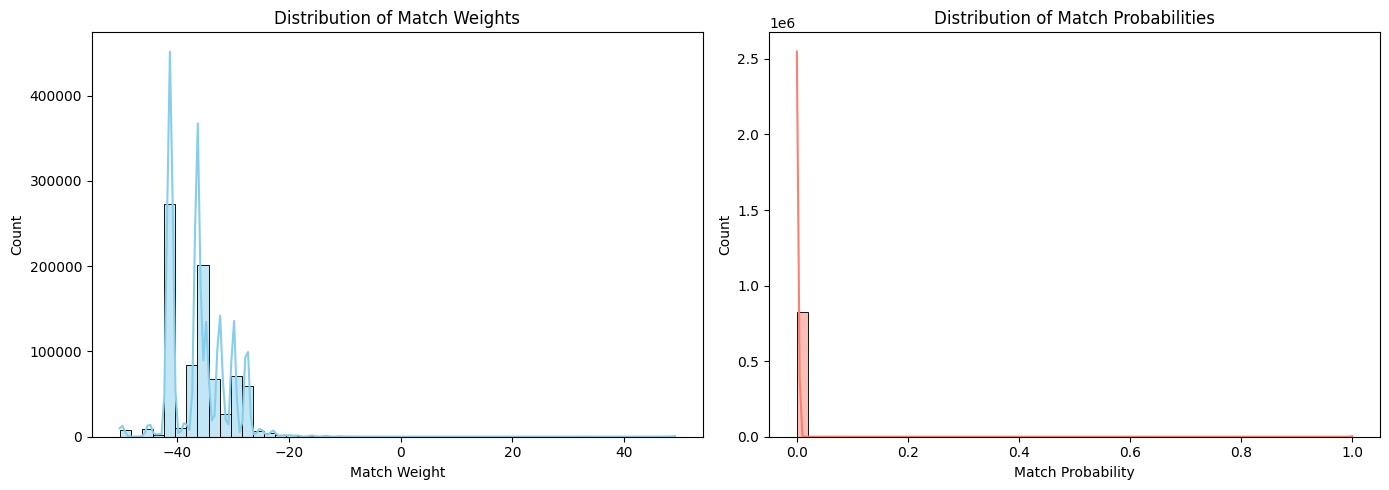

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the Splink object is converted to a Pandas DataFrame
df_pandas = df_results

# Create a two-panel distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Match Weight Distribution (Linear scale, e.g., -10 to +30)
sns.histplot(data=df_pandas, x="match_weight", bins=50, ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Distribution of Match Weights")
axes[0].set_xlabel("Match Weight")

# Panel 2: Match Probability Distribution (S-curve squeezed between 0 and 1)
sns.histplot(data=df_pandas, x="match_probability", bins=50, ax=axes[1], color="salmon", kde=True)
axes[1].set_title("Distribution of Match Probabilities")
axes[1].set_xlabel("Match Probability")

plt.tight_layout()
plt.show()

In [42]:
df_results

,match_weight,match_probability,source_dataset_l,source_dataset_r,CID_l,CID_r,artist_l,artist_r,gamma_artist,bf_artist,...,bf_year_options,number_l,number_r,gamma_number,bf_number,CTID_l,CTID_r,uai_l,uai_r,match_key
0,-41.163415,4.060481e-13,__splink__input_table_0,__splink__input_table_1,7464,117,三遊亭圓生,Dexter Gordon,0,0.090234,...,0.03213,2.0,2.0,1,16.863659,1,1,uai_2272,uai_230,1
1,-41.163415,4.060481e-13,__splink__input_table_0,__splink__input_table_1,7491,117,岩崎英則,Dexter Gordon,0,0.090234,...,0.03213,2.0,2.0,1,16.863659,1,1,uai_4039,uai_230,1
2,-38.147318,3.284832e-12,__splink__input_table_0,__splink__input_table_1,7521,303,None,Alfee,-1,1.000000,...,0.03213,1.0,1.0,1,16.863659,1,2,uai_592,uai_3381,1
3,-41.163415,4.060481e-13,__splink__input_table_0,__splink__input_table_1,7526,303,Deepgroove & Jamie Anderson,Alfee,0,0.090234,...,0.03213,1.0,1.0,1,16.863659,1,2,uai_5620,uai_3381,1
4,-41.163415,4.060481e-13,__splink__input_table_0,__splink__input_table_1,7528,303,Bill Evans,Alfee,0,0.090234,...,0.03213,1.0,1.0,1,16.863659,1,2,uai_5662,uai_3381,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829659,-41.617506,2.964029e-13,__splink__input_table_0,__splink__input_table_1,4971,1633,Juha Tapio,Klever,0,0.090234,...,0.03213,5.0,5.0,1,16.863659,2,1,uai_3157,uai_2576,1
829660,-27.545757,5.103886e-09,__splink__input_table_0,__splink__input_table_1,5483,9089,Pearl Jam,Lola Beltrán,0,0.090234,...,1.00000,3.0,3.0,1,16.863659,4,3,uai_560,uai_962,1
829661,-29.922730,9.825634e-10,__splink__input_table_0,__splink__input_table_1,6863,6496,Eddiemuerte,Jonathan Stockstill,0,0.090234,...,1.00000,4.0,4.0,1,16.863659,5,2,uai_847,uai_3468,1
829662,-32.505672,1.639902e-10,__splink__input_table_0,__splink__input_table_1,1232,387,Kryštof,Giants of Science,0,0.090234,...,0.03213,8.0,8.0,1,16.863659,1,1,uai_2560,uai_1856,1


In [46]:
df_results.to_parquet("../local_predicts/music_predictions.parquet", index=False)
model_path = "../local_predicts/music_splink_model.json"
linker.misc.save_model_to_json(model_path, overwrite=True)

{'link_type': 'link_only',
 'probability_two_random_records_match': 6.73096849825495e-05,
 'retain_matching_columns': True,
 'retain_intermediate_calculation_columns': True,
 'additional_columns_to_retain': ['CID', 'CTID', 'uai'],
 'sql_dialect': 'duckdb',
 'linker_uid': 'poyj5yrz',
 'em_convergence': 0.0001,
 'max_iterations': 25,
 'bayes_factor_column_prefix': 'bf_',
 'term_frequency_adjustment_column_prefix': 'tf_',
 'comparison_vector_value_column_prefix': 'gamma_',
 'unique_id_column_name': 'CID',
 'source_dataset_column_name': 'source_dataset',
 'blocking_rules_to_generate_predictions': [{'blocking_rule': '\n    (l.artist = r.artist)\n    ',
   'sql_dialect': 'duckdb'},
  {'blocking_rule': '\n    (l.number = r.number)\n    ',
   'sql_dialect': 'duckdb'},
  {'blocking_rule': '\n    SUBSTR(l.title, 1, 4) = SUBSTR(r.title, 1, 4)\n    ',
   'sql_dialect': 'duckdb'}],
 'comparisons': [{'output_column_name': 'artist',
   'comparison_levels': [{'sql_condition': '"artist_l" IS NULL OR "a

In [47]:
matches = df_results[df_results["CID_l"] == df_results["CID_r"]]
non_matches = df_results[df_results["CID_l"] != df_results["CID_r"]]

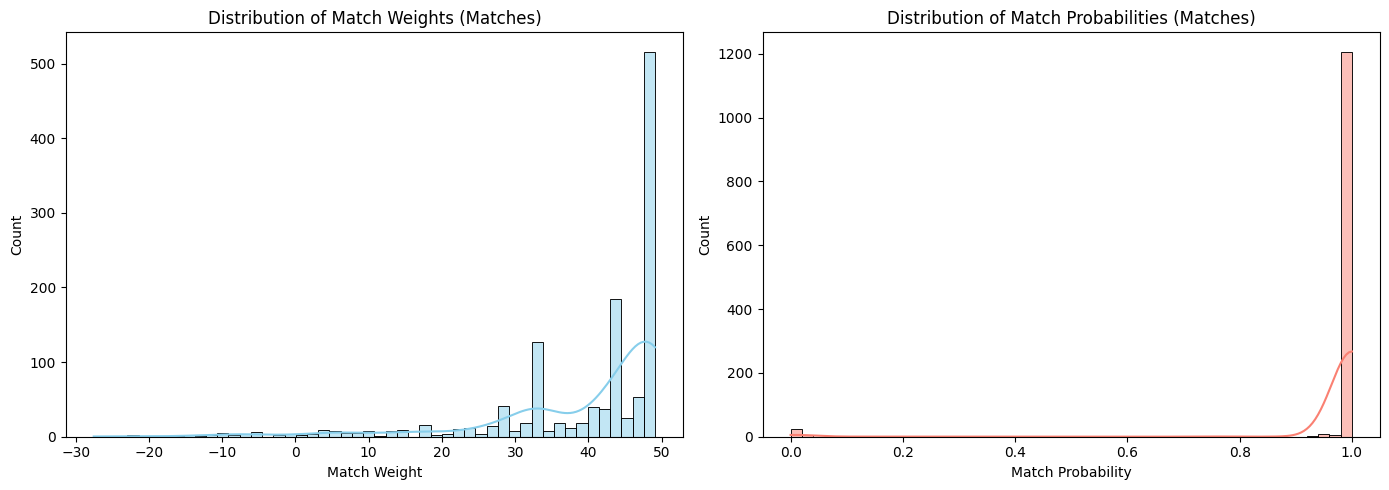

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Match Weight Distribution
sns.histplot(data=matches, x="match_weight", bins=50, ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Distribution of Match Weights (Matches)")
axes[0].set_xlabel("Match Weight")

# Panel 2: Match Probability Distribution (S-curve squeezed between 0 and 1)
sns.histplot(data=matches, x="match_probability", bins=50, ax=axes[1], color="salmon", kde=True)
axes[1].set_title("Distribution of Match Probabilities (Matches)")
axes[1].set_xlabel("Match Probability")

plt.tight_layout()
plt.show()

In [49]:
core_cols = ['match_probability', 'match_weight', 'uai_l', 'uai_r']
metadata_cols = ['title_l', 'title_r', 'artist_l', 'artist_r', 'album_l', 'album_r', 'number_l', 'number_r']

# 2. Extract every Bayes Factor (bf_) column generated by your settings
bf_cols = [col for col in matches.columns if col.startswith('bf_')]

# 3. Combine them into a clean, comprehensive viewing grid
inspection_df = matches[core_cols + metadata_cols + bf_cols].copy()

# Set Pandas formatting options so numbers do not truncate or convert to scientific notation
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 4. Display a snapshot of problematic cases (Low probability matches)
print("--- AMBIGUOUS/LOW CONFIDENCE CANDIDATES (Probability < 50%) ---")
low_conf = inspection_df[inspection_df['match_probability'] < 0.50].head(10)
display(low_conf)

# 5. Display a snapshot of highly confident matches (Probability = 100%)
print("\n--- HIGH CONFIDENCE MATCHES (Probability > 95%) ---")
high_conf = inspection_df[inspection_df['match_probability'] > 0.95].head(10)
display(high_conf)# 1. Define the core fields we want to inspect



--- AMBIGUOUS/LOW CONFIDENCE CANDIDATES (Probability < 50%) ---


,match_probability,match_weight,uai_l,uai_r,title_l,title_r,artist_l,artist_r,album_l,album_r,number_l,number_r,bf_artist,bf_title_lexical,bf_title_tokens,bf_album,bf_length_ms,bf_year_options,bf_number
10065,2.341398e-03,-8.735032,uai_4626,uai_4769,LOVEPOTION #9,#9,BEAT CRUSADERS,BEAT-CRUSADERS,OVEPOTION #9,LOVEPOTION #9,1.0,1.0,1685.015295,0.012693,0.004788,0.157837,5.19446,24.62395,16.863659
91671,4.870212e-01,-0.074915,uai_2514,uai_1782,Yasuragi [Tranquility] - Rurouni Kenshin Compl...,Yasuragi [Tranquility],朝倉行,朝倉紀行,Original Soundtrack Game II,Rurouni Kenshin Complete CD-BOX - Scene 9 - Or...,9.0,9.0,1685.015295,126.441283,0.004788,0.157837,5.19446,1.00000,16.863659
113351,1.256778e-07,-22.923766,uai_1848,uai_736,CHEWIN' MAMA BLUES,Chewin' Mama Blues,DINAH WASHINGTON,Dinah Washington,LADY SINGS THE BLUES,Lady Sings the Blues,3.0,3.0,0.090234,0.012693,0.004788,0.157837,5.19446,24.62395,16.863659
121191,3.761408e-04,-11.375897,uai_4965,uai_2614,aPssion Flower l- In Motion,Passion Flower,Heath Brothers,The Heath Brothers,None,In Motion,5.0,5.0,0.090234,0.012693,2.262621,1.000000,5.19446,24.62395,16.863659
203856,1.465124e-02,-6.071540,uai_2586,uai_3274,1,Kissing,Mandaaly,Mandaly,None,Sampler,1.0,1.0,1685.015295,0.012693,0.004788,1.000000,5.19446,24.62395,16.863659
339949,3.761408e-04,-11.375897,uai_1479,uai_4717,TheyWon'tStopTroopsofTomorrow,They Won't Stop,Exploited,The Exploited,None,Troops of Tomorrow,11.0,11.0,0.090234,0.012693,2.262621,1.000000,5.19446,24.62395,16.863659
344008,1.267876e-01,-2.783920,uai_4754,uai_592,Personent Hodie (Sing Aloud on This Day),None,Bob James,None,Warner Bros. Jazz Christmas Party,None,11.0,11.0,1.000000,1.000000,1.000000,1.000000,5.19446,24.62395,16.863659
378695,8.083095e-03,-6.939168,uai_2588,uai_1434,美勇伝,恋する♡エンジェル♡ハート (Instrumental),恋する♡エンジェル♡ハート (Instrumental),美勇伝,恋する♡エンジェル♡ハート,恋する♡エンジェル♡ハート,3.0,3.0,0.090234,0.012693,0.004788,10234.166891,5.19446,24.62395,16.863659
429439,7.962502e-07,-20.260274,uai_3073,uai_3366,unk.,Fakin' the Funk,Source,MainSource,None,White Men Can't Rap,3.0,3.0,0.090234,0.012693,0.004788,1.000000,5.19446,24.62395,16.863659
469436,5.103886e-09,-27.545757,uai_5785,uai_3391,Frühstückskorn - All die ganzen Jahre: Rarität...,FRÜHSTÜCKSKORN,Toten Hosen,Die Toten Hosen,'95,All die ganzen Jahre: Raritäten ’79–’84,24.0,24.0,0.090234,0.012693,0.004788,0.157837,5.19446,1.00000,16.863659



--- HIGH CONFIDENCE MATCHES (Probability > 95%) ---


,match_probability,match_weight,uai_l,uai_r,title_l,title_r,artist_l,artist_r,album_l,album_r,number_l,number_r,bf_artist,bf_title_lexical,bf_title_tokens,bf_album,bf_length_ms,bf_year_options,bf_number
23387,1.0,45.263124,uai_3651,uai_2128,デタラメな残像,デタラメな残像,GRANRODEO,GRANROqDEO,デタラメな残像,デタラメな残像,1.0,1.0,1685.015295,9940.639543,8811.930787,10234.166891,1.00000,24.62395,16.863659
28667,1.0,32.371814,uai_4059,uai_3222,Santa Claus Is Coming to Town,Santa Cllaus Is Coming to Town,Ventuers,The Ventures,The Ventures’ Christmas Album,The Ventures’ Christmas Album,3.0,3.0,0.090234,4703.675977,8811.930787,10234.166891,5.19446,24.62395,16.863659
35301,1.0,43.018108,uai_5145,uai_5851,On the Bank,On the Bank,Rude Rich and the High Notes,Rude-Rich-and-the-High-Notes,Soul Stomp,Soul Stomp,4.0,4.0,1685.015295,9940.639543,8811.930787,10234.166891,5.19446,1.00000,16.863659
40072,1.0,47.640098,uai_1893,uai_4401,Στα καμένα,Στα καμένα,Λαυρέντης Μαχαιρίτσας,Λαυρέντης Μαχαιρίίτσας,"Συλλογή Δίφωνο, 22: Μουσικοί βιότοποι","Συλλογή Δίφωνο, 22: Μουσικοί βιότοποι",4.0,4.0,1685.015295,9940.639543,8811.930787,10234.166891,5.19446,24.62395,16.863659
42900,1.0,47.640098,uai_4635,uai_1097,Winterreise,Winterreise,Atom™,Atmo™,Winterreise,Winterreise,1.0,1.0,1685.015295,9940.639543,8811.930787,10234.166891,5.19446,24.62395,16.863659
43008,1.0,35.681219,uai_4917,uai_6066,Makin' Out With Granny,Makin' Out With Granny,Falling Mirror,Falling Mirror Mirror,Zen Boulders,Zen Boulders,3.0,3.0,1685.015295,9940.639543,8811.930787,10234.166891,1.00000,0.03213,16.863659
44714,1.0,47.640098,uai_4615,uai_4479,Nattestid ser porten vid 1,Nattestid ser porten vid 1,lTaake,Taake,Nattestid…,Nattestid…,1.0,1.0,1685.015295,9940.639543,8811.930787,10234.166891,5.19446,24.62395,16.863659
46688,1.0,43.018108,uai_2116,uai_1224,Jivin' (in a Jump Swing Band),Jivin' (in a Jump Swing Band),Kamikaze Mustang,Kamikaze Mustang Pilot,Kamikaze Mustang Pilot,Kamikaze Mustang Pilot,3.0,3.0,1685.015295,9940.639543,8811.930787,10234.166891,5.19446,1.00000,16.863659
54745,1.0,46.560548,uai_2808,uai_3831,Conditionierer,oCnditionierer,Moebius & Plank,Mobius & Plank,Begegnungen II,Begegnungen II,1.0,1.0,1685.015295,4703.675977,8811.930787,10234.166891,5.19446,24.62395,16.863659
57363,1.0,27.749824,uai_1622,uai_4849,Männer (radio mix),Männer (radioo mix),Zigaretten feat. Rosa,Zigaretten Rauchen Rauchen feat. Rosa,Männer,Männer,1.0,1.0,0.090234,4703.675977,8811.930787,10234.166891,5.19446,1.00000,16.863659


In [50]:
# 2. Extract every Bayes Factor (bf_) column generated by your settings
bf_cols = [col for col in non_matches.columns if col.startswith('bf_')]

# 3. Combine them into a clean, comprehensive viewing grid
inspection_df = non_matches[core_cols + metadata_cols + bf_cols].copy()

# Set Pandas formatting options so numbers do not truncate or convert to scientific notation
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 4. Display a snapshot of problematic cases (Low probability non_matches)
print("--- AMBIGUOUS/LOW CONFIDENCE CANDIDATES (Probability < 50%) ---")
low_conf = inspection_df[inspection_df['match_probability'] < 0.50].head(10)
display(low_conf)

# 5. Display a snapshot of highly confident non_matches (Probability = 100%)
print("\n--- HIGH CONFIDENCE non_matches (Probability > 95%) ---")
high_conf = inspection_df[inspection_df['match_probability'] > 0.95].head(10)
display(high_conf)

--- AMBIGUOUS/LOW CONFIDENCE CANDIDATES (Probability < 50%) ---


,match_probability,match_weight,uai_l,uai_r,title_l,title_r,artist_l,artist_r,album_l,album_r,number_l,number_r,bf_artist,bf_title_lexical,bf_title_tokens,bf_album,bf_length_ms,bf_year_options,bf_number
0,4.060481e-13,-41.163415,uai_2272,uai_230,三十石,Three O'Clock in the Morning,三遊亭圓生,Dexter Gordon,圓生特選ライヴ 3 淀五郎/三十石,The Classic Blue Note Recordings,2.0,2.0,0.090234,0.012693,0.004788,0.157837,0.012862,0.03213,16.863659
1,4.060481e-13,-41.163415,uai_4039,uai_230,For Home and Country,Three O'Clock in the Morning,岩崎英則,Dexter Gordon,FRONT MISSION 5 〜Scars of the War〜 OST,The Classic Blue Note Recordings,2.0,2.0,0.090234,0.012693,0.004788,0.157837,0.012862,0.03213,16.863659
2,3.284832e-12,-38.147318,uai_592,uai_3381,Train,See You Again,None,Alfee,Train,"doubt,",1.0,1.0,1.000000,0.012693,0.004788,0.157837,0.009389,0.03213,16.863659
3,4.060481e-13,-41.163415,uai_5620,uai_3381,The Clock,See You Again,Deepgroove & Jamie Anderson,Alfee,The Clock,"doubt,",1.0,1.0,0.090234,0.012693,0.004788,0.157837,0.012862,0.03213,16.863659
4,4.060481e-13,-41.163415,uai_5662,uai_3381,"I Got it Bad, And That Ain't Good",See You Again,Bill Evans,Alfee,Jazz Piano History,"doubt,",1.0,1.0,0.090234,0.012693,0.004788,0.157837,0.012862,0.03213,16.863659
5,1.639902e-10,-32.505672,uai_254,uai_3381,Poland,See You Again,Ganache,Alfee,"The Lifted Brow, No. 6","doubt,",1.0,1.0,0.090234,0.012693,0.004788,0.157837,5.194460,0.03213,16.863659
6,1.263748e-11,-36.203500,uai_5032,uai_3381,... E mi consuma l'estate,See You Again,Fred Bongusto,Alfee,Ore d'amore,"doubt,",1.0,1.0,0.090234,0.012693,0.004788,0.157837,0.012862,1.00000,16.863659
7,2.964029e-13,-41.617506,uai_441,uai_3381,Funkalific,See You Again,Ray Anderson,Alfee,Every One Of Us,"doubt,",1.0,1.0,0.090234,0.012693,0.004788,0.157837,0.009389,0.03213,16.863659
8,2.964029e-13,-41.617506,uai_2281,uai_3381,Hay! Hay! Hay! (Radio Edit),See You Again,Brigs,Alfee,Hay! Hay! Hay!,"doubt,",1.0,1.0,0.090234,0.012693,0.004788,0.157837,0.009389,0.03213,16.863659
9,2.964029e-13,-41.617506,uai_4958,uai_230,The Takedown,Three O'Clock in the Morning,UAgly Duckling,Dexter Gordon,Audacity,The Classic Blue Note Recordings,2.0,2.0,0.090234,0.012693,0.004788,0.157837,0.009389,0.03213,16.863659



--- HIGH CONFIDENCE non_matches (Probability > 95%) ---


,match_probability,match_weight,uai_l,uai_r,title_l,title_r,artist_l,artist_r,album_l,album_r,number_l,number_r,bf_artist,bf_title_lexical,bf_title_tokens,bf_album,bf_length_ms,bf_year_options,bf_number
61674,0.988232,6.391955,uai_1141,uai_5249,2,2,3.8n83,InnerWish,Craig David,Silent Faces,NaN,2.0,0.090234,9940.639543,8811.930787,0.157837,1.00000,1.00000,1.000000
62221,0.995306,7.728272,uai_2548,uai_4404,Wake Me Up,Wake Up,Figure of Six,Hooverphonic,Step One,No More Sweet Music,11.0,9.0,0.090234,4703.675977,8811.930787,0.157837,5.19446,24.62395,0.041721
62435,0.988232,6.391955,uai_1141,uai_14,2,2,3.8n83,Johann Sebastian Bach,Craig David,"Bach 2000: The Complete Bach Edition, Volume 1...",NaN,8.0,0.090234,9940.639543,8811.930787,0.157837,1.00000,1.00000,1.000000
63530,0.988232,6.391955,uai_4064,uai_2034,[untitled],[untitled],Crasten Fietz,The Residents,Treibstoff,Kettles of Fish on the Outskirts of Town,NaN,20.0,0.090234,9940.639543,8811.930787,0.157837,1.00000,1.00000,1.000000
64011,0.998124,9.055448,uai_4405,uai_3847,[untitled],[untitled],David DeAngelo,WB Loops,None,Vinyl Wunderwaffe Volume II,16.0,NaN,0.090234,9940.639543,8811.930787,1.000000,1.00000,1.00000,1.000000
64016,0.988232,6.391955,uai_692,uai_3847,[untitled],[untitled],Howard Blake,WB Loops,The Canterville Ghost,Vinyl Wunderwaffe Volume II,19.0,NaN,0.090234,9940.639543,8811.930787,0.157837,1.00000,1.00000,1.000000
64058,0.988232,6.391955,uai_4434,uai_3847,[untitled],[untitled],Helgoland,WB Loops,Helgoland and Band 99,Vinyl Wunderwaffe Volume II,90.0,NaN,0.090234,9940.639543,8811.930787,0.157837,1.00000,1.00000,1.000000
64148,0.988232,6.391955,uai_1392,uai_3847,[untitled],[untitled],Bill Clinton,WB Loops,"My Life, Part 1",Vinyl Wunderwaffe Volume II,4.0,NaN,0.090234,9940.639543,8811.930787,0.157837,1.00000,1.00000,1.000000
64282,0.956893,4.472351,uai_4405,uai_692,[untitled],[untitled],David DeAngelo,Howard Blake,None,The Canterville Ghost,16.0,19.0,0.090234,9940.639543,8811.930787,1.000000,1.00000,1.00000,0.041721
64436,0.988232,6.391955,uai_4064,uai_692,[untitled],[untitled],Crasten Fietz,Howard Blake,Treibstoff,The Canterville Ghost,NaN,19.0,0.090234,9940.639543,8811.930787,0.157837,1.00000,1.00000,1.000000


In [51]:

# ==========================================
# STEP 1: Discover Splink's Internal Dataset Names
# ==========================================
# Get the exact keys Splink uses internally to label the left and right datasets
dataset_names = list(linker._input_tables_dict.keys())
print(f"DEBUG: Splink recognizes your datasets as: {dataset_names}")

# Assign them cleanly based on their registration sequence
internal_name_df1 = dataset_names[0]
internal_name_df2 = dataset_names[1]


# ==========================================
# STEP 2: Standardise and Extract Common Identifiers
# ==========================================
# Get common IDs and ensure they are read purely as identical string types
ids_df1 = df1[['CID']].copy().rename(columns={'CID': 'CID_l'})
ids_df2 = df2[['CID']].copy().rename(columns={'CID': 'CID_r'})

raw_matches = ids_df1.merge(ids_df2, left_on='CID_l', right_on='CID_r')


# ==========================================
# STEP 3: Enforce Exact Splink Alphabetical Left-Right Sort Order
# ==========================================
labels_df = pd.DataFrame()
labels_df["CID_l"] = raw_matches["CID_l"]
labels_df["CID_r"] = raw_matches["CID_r"]
labels_df["source_dataset_l"] = internal_name_df1
labels_df["source_dataset_r"] = internal_name_df2
labels_df["clerical_match_score"] = 1.0

# Splink drops labels if concat(source_l, id_l) > concat(source_r, id_r)
concat_l = labels_df["source_dataset_l"] + "-__-" + labels_df["CID_l"].to_string()
concat_r = labels_df["source_dataset_r"] + "-__-" + labels_df["CID_r"].to_string()
swap_mask = concat_l > concat_r

if swap_mask.any():
    # Correct source datasets orientation
    labels_df.loc[swap_mask, ["source_dataset_l", "source_dataset_r"]] = \
        labels_df.loc[swap_mask, ["source_dataset_r", "source_dataset_l"]].values
    # Correct corresponding ID orientation
    labels_df.loc[swap_mask, ["CID_l", "CID_r"]] = \
        labels_df.loc[swap_mask, ["CID_r", "CID_l"]].values


# ==========================================
# STEP 4: Safely Overwrite and Register Table Pointers
# ==========================================
try:
    linker.misc.query_sql("DROP TABLE IF EXISTS my_ground_truth_labels")
except Exception:
    pass

labels_table = linker.table_management.register_labels_table(labels_df, overwrite=True)
print(f"Success: Registered {len(labels_df)} ground-truth rows with Splink's structural format.")


# ==========================================
# STEP 5: Force Prediction & Extract Accuracy Metrics
# ==========================================
# Ensure a prediction pass has run so intermediate tables are active
print("Calculating link pairs...")
pred = linker.inference.predict() 

# Extract the metrics
try:
    roc_metrics_df = linker.evaluation.accuracy_analysis_from_labels_table(
        labels_table, 
        output_type="table",
        add_metrics=["f1", "accuracy"]
    ).as_pandas_dataframe()
    
    print(f"Evaluation succeeded! Rows generated: {len(roc_metrics_df)}")
except Exception as err:
    print(f"Failed during evaluation compilation: {err}")


DEBUG: Splink recognizes your datasets as: ['__splink__input_table_0', '__splink__input_table_1']


'CREATE TABLE __splink__df_sql_query_d9e1c1c1c AS 
DROP TABLE IF EXISTS my_ground_truth_labels' contains unsupported syntax. Falling back to parsing as a 'Command'.


Success: Registered 1266 ground-truth rows with Splink's structural format.
Calculating link pairs...


Blocking time: 0.23 seconds
Predict time: 0.16 seconds


Evaluation succeeded! Rows generated: 142


In [52]:
linker.evaluation.accuracy_analysis_from_labels_table(
    labels_table, 
    add_metrics=["f1", "accuracy"],
    output_type="threshold_selection"
)


alt.HConcatChart(...)

In [53]:
left_counts  = df1_clean["uai"].value_counts()   # Series: id → frequency in df1
right_counts = df2_clean["uai"].value_counts()   # Series: id → frequency in df2

agg_df = (
    df_results[
        ['uai_l', 'uai_r','match_probability']
    ]
    .groupby(['uai_l', 'uai_r'], as_index=False, dropna=False)
    .agg({'match_probability': sum})
)

agg_df

/tmp/ipykernel_1250515/105722358.py:9: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'match_probability': sum})


,uai_l,uai_r,match_probability
0,uai_0,uai_0,1.000000e+00
1,uai_0,uai_100,5.327704e-13
2,uai_0,uai_1007,2.964029e-13
3,uai_0,uai_1012,9.825634e-10
4,uai_0,uai_1018,4.060481e-13
...,...,...,...
804891,uai_999,uai_8,2.964029e-13
804892,uai_999,uai_864,4.060481e-13
804893,uai_999,uai_892,9.224984e-12
804894,uai_999,uai_897,2.282254e-14


In [54]:
unique_l = left_counts.index
unique_r = right_counts.index

# Cartesian product of the observed ids (still a DataFrame)
pair_keys = pd.MultiIndex.from_product(
    [unique_l, unique_r],
    names=["uai_l", "uai_r"]
).to_frame(index=False)

# Attach the left and right counts
pair_keys = pair_keys.merge(
    left_counts.rename("left_count"),
    left_on="uai_l",
    right_index=True,
    how="left"
).merge(
    right_counts.rename("right_count"),
    left_on="uai_r",
    right_index=True,
    how="left"
)

# Pair‑specific denominator = left_count × right_count
pair_keys["pair_size"] = pair_keys["left_count"] * pair_keys["right_count"]

# -------------------------------------------------
# 4️⃣  Join the aggregated probabilities to the pair‑specific sizes
# -------------------------------------------------
# ---------------------------------------------------------------------------
# 4️⃣ Join the aggregated probabilities using an INNER join to drop NaNs
# ---------------------------------------------------------------------------
norm_df = pair_keys.merge(
    agg_df,
    on=["uai_l", "uai_r"],
    how="inner" # Drops any unobserved pairs instantly
)

# Calculate your normalized metrics only on the pairs that survived
norm_df["norm_match_prob"] = norm_df["match_probability"] / norm_df["pair_size"]

norm_df


,uai_l,uai_r,left_count,right_count,pair_size,match_probability,norm_match_prob
0,uai_14,uai_14,22,24,528,1.095226e+01,2.074292e-02
1,uai_14,uai_592,22,23,506,7.100979e-05,1.403355e-07
2,uai_14,uai_348,22,12,264,1.043227e-08,3.951616e-11
3,uai_14,uai_718,22,12,264,5.180882e-09,1.962455e-11
4,uai_14,uai_328,22,7,154,8.586199e-11,5.575454e-13
...,...,...,...,...,...,...,...
804891,uai_5145,uai_71,1,1,1,9.224984e-12,9.224984e-12
804892,uai_5145,uai_2419,1,1,1,1.263748e-11,1.263748e-11
804893,uai_5145,uai_50,1,1,1,9.224984e-12,9.224984e-12
804894,uai_5145,uai_6016,1,1,1,9.825634e-10,9.825634e-10


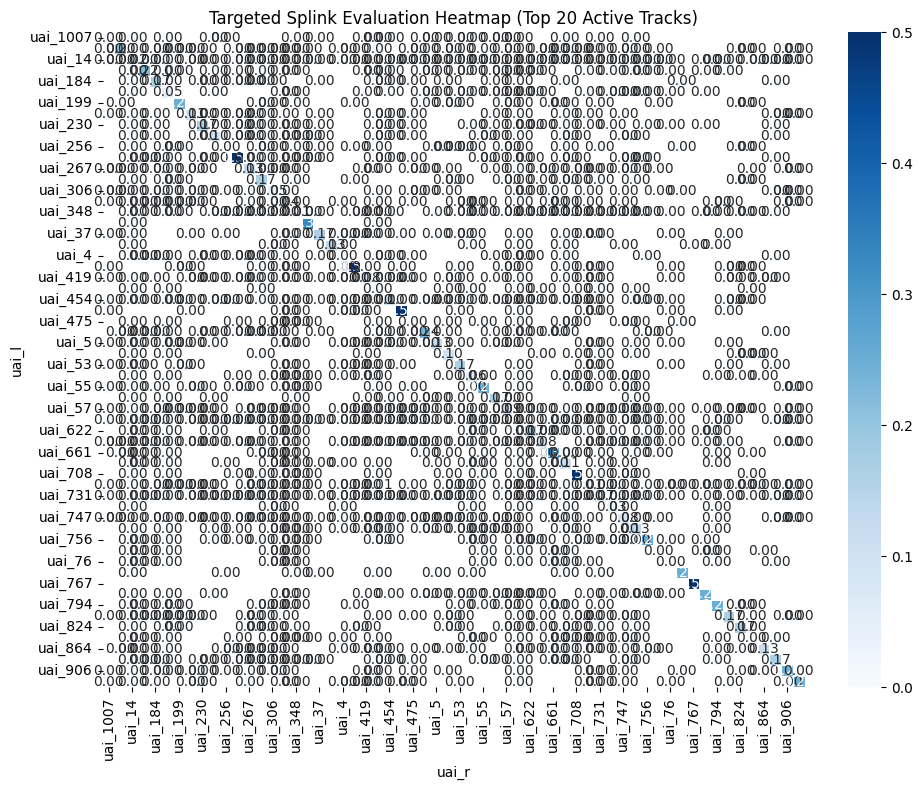

In [55]:
# 1. Identify the most active ground truth track IDs
top_entities = norm_df[norm_df['uai_l'] == norm_df['uai_r']].nlargest(60, 'pair_size')['uai_l']

# 2. Slice the matrix strictly to interactions involving these top entities
dense_subset = norm_df[norm_df['uai_l'].isin(top_entities) & norm_df['uai_r'].isin(top_entities)]

# 3. Pivot ONLY this small dense subset (Safe from memory drops)
mat_sub = dense_subset.pivot(index='uai_l', columns='uai_r', values='norm_match_prob')

# 4. Render the targeted heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    mat_sub,
    cmap='Blues',           # Sequential map works better here since numbers are 0 to 1
    mask=mat_sub.isna(),
    linewidths=.5,
    annot=True,             # Write numbers inside cells for explicit tracking
    fmt=".2f"
)
plt.title('Targeted Splink Evaluation Heatmap (Top 20 Active Tracks)')
plt.tight_layout()
plt.show()


In [56]:
import numpy as np
import pandas as pd

# 1. Establish the absolute baseline of true connections in your ground truth
# (Every unique track ID matching with itself)
total_possible_true_matches = len(left_counts.index.intersection(right_counts.index))

# 2. Generate a spectrum of threshold checkpoints
thresholds = np.linspace(0.05, 0.95, 19)
pr_results = []

for t in thresholds:
    # Flag predicted pairs that clear the current normalization threshold
    predicted_pairs = norm_df[norm_df['norm_match_prob'] >= t]
    
    # Calculate True Positives (On the diagonal)
    tp = len(predicted_pairs[predicted_pairs['uai_l'] == predicted_pairs['uai_r']])
    
    # Calculate False Positives (Off the diagonal)
    fp = len(predicted_pairs[predicted_pairs['uai_l'] != predicted_pairs['uai_r']])
    
    # Deriving structural evaluation metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / total_possible_true_matches if total_possible_true_matches > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    pr_results.append({
        'Threshold': round(t, 2),
        'True_Positives': tp,
        'False_Positives': fp,
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1_Score': round(f1, 4)
    })

# Convert to tracking DataFrame for analysis
pr_curve_df = pd.DataFrame(pr_results)
display(pr_curve_df)


,Threshold,True_Positives,False_Positives,Precision,Recall,F1_Score
0,0.05,912,424,0.6826,0.8653,0.7632
1,0.10,904,416,0.6848,0.8577,0.7616
2,0.15,894,399,0.6914,0.8482,0.7618
3,0.20,884,393,0.6922,0.8387,0.7585
4,0.25,881,380,0.6987,0.8359,0.7611
5,0.30,869,376,0.6980,0.8245,0.7560
6,0.35,860,368,0.7003,0.8159,0.7537
7,0.40,859,352,0.7093,0.8150,0.7585
8,0.45,859,346,0.7129,0.8150,0.7605
9,0.50,851,319,0.7274,0.8074,0.7653


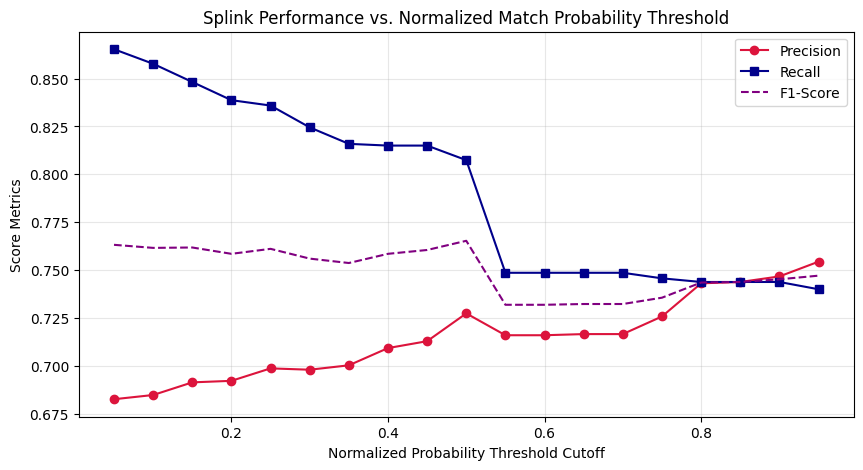

In [57]:
plt.figure(figsize=(10, 5))
plt.plot(pr_curve_df['Threshold'], pr_curve_df['Precision'], label='Precision', marker='o', color='crimson')
plt.plot(pr_curve_df['Threshold'], pr_curve_df['Recall'], label='Recall', marker='s', color='darkblue')
plt.plot(pr_curve_df['Threshold'], pr_curve_df['F1_Score'], label='F1-Score', linestyle='--', color='purple')

plt.title('Splink Performance vs. Normalized Match Probability Threshold')
plt.xlabel('Normalized Probability Threshold Cutoff')
plt.ylabel('Score Metrics')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [58]:
global_matches = norm_df[norm_df["uai_l"] == norm_df["uai_r"]]
global_matches.sort_values(by="norm_match_prob")

,uai_l,uai_r,left_count,right_count,pair_size,match_probability,norm_match_prob
656846,uai_280,uai_280,1,1,1,3.740246e-11,3.740246e-11
536682,uai_896,uai_896,1,1,1,3.740246e-11,3.740246e-11
669169,uai_276,uai_276,1,1,1,3.740246e-11,3.740246e-11
725516,uai_599,uai_599,1,1,1,3.740246e-11,3.740246e-11
229000,uai_450,uai_450,1,1,1,3.740246e-11,3.740246e-11
...,...,...,...,...,...,...,...
784734,uai_704,uai_704,1,1,1,1.000000e+00,1.000000e+00
94467,uai_74,uai_74,1,1,1,1.000000e+00,1.000000e+00
94161,uai_543,uai_543,1,1,1,1.000000e+00,1.000000e+00
92781,uai_744,uai_744,1,1,1,1.000000e+00,1.000000e+00


In [59]:
global_non_matches = norm_df[norm_df["uai_l"] != norm_df["uai_r"]]
global_non_matches.sort_values(by="norm_match_prob")

,uai_l,uai_r,left_count,right_count,pair_size,match_probability,norm_match_prob
2471,uai_348,uai_569,13,2,26,7.332986e-16,2.820379e-17
172,uai_14,uai_301,22,1,22,7.332986e-16,3.333175e-17
2439,uai_348,uai_454,13,2,26,1.004560e-15,3.863692e-17
2410,uai_348,uai_665,13,2,26,1.004560e-15,3.863692e-17
20511,uai_864,uai_424,4,6,24,1.004560e-15,4.185666e-17
...,...,...,...,...,...,...,...
795891,uai_4507,uai_5532,1,1,1,1.000000e+00,1.000000e+00
490792,uai_5465,uai_4176,1,1,1,1.000000e+00,1.000000e+00
743356,uai_5555,uai_2793,1,1,1,1.000000e+00,1.000000e+00
644790,uai_4291,uai_4032,1,1,1,1.000000e+00,1.000000e+00
